In [11]:
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import os
import sys

In [34]:
sys.path.append(os.path.abspath(os.path.join('..', '..')))

from carvana.config import *
from carvana.dataset.dataset import CarvanaDataset
from carvana.dataset.transforms import get_transforms
from carvana.train.losses import *
from carvana.train.trainer import run_training
from carvana.train.utils import *

In [13]:
train_transform = get_transforms(image_size=IMAGE_SIZE, is_train=True)
val_transform = get_transforms(image_size=IMAGE_SIZE, is_train=False)

full_dataset = CarvanaDataset(
    images_dir=TRAIN_IMAGES_DIR,
    masks_dir=TRAIN_MASKS_DIR,
    normalize_mask=True
)


In [14]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

In [15]:
train_subset.dataset.transform = train_transform
val_subset.dataset.transform = val_transform

In [16]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
model_BCE = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

In [18]:
optimizer_BCE = torch.optim.Adam(model_BCE.parameters(), lr=LEARNING_RATE)

In [19]:
loss_BCE = BCELoss

Training: 100%|██████████| 255/255 [02:24<00:00,  1.77it/s, iou=0.971, loss=0.0543]


[*] Лучшая модель сохранена (IoU: 0.9722)
Epoch 01 | Val Loss: 0.0543 | IoU: 0.9722 | Dice: 0.9859


Training: 100%|██████████| 255/255 [02:25<00:00,  1.75it/s, iou=0.979, loss=0.0285]


[*] Лучшая модель сохранена (IoU: 0.9766)
Epoch 02 | Val Loss: 0.0293 | IoU: 0.9766 | Dice: 0.9882


Training: 100%|██████████| 255/255 [02:24<00:00,  1.76it/s, iou=0.978, loss=0.0213]


...

[*] Лучшая модель сохранена (IoU: 0.9817)
[EarlyStopping] Счетчик: 1 из 3
Epoch 05 | Val Loss: 0.0130 | IoU: 0.9817 | Dice: 0.9908


Training: 100%|██████████| 255/255 [02:30<00:00,  1.70it/s, iou=0.984, loss=0.0115]


[*] Лучшая модель сохранена (IoU: 0.9823)
[EarlyStopping] Счетчик: 2 из 3
Epoch 06 | Val Loss: 0.0117 | IoU: 0.9823 | Dice: 0.9910


Training: 100%|██████████| 255/255 [02:30<00:00,  1.70it/s, iou=0.986, loss=0.00967]


[*] Лучшая модель сохранена (IoU: 0.9830)
[EarlyStopping] Счетчик: 3 из 3
Ранняя остановка на 07 эпохе


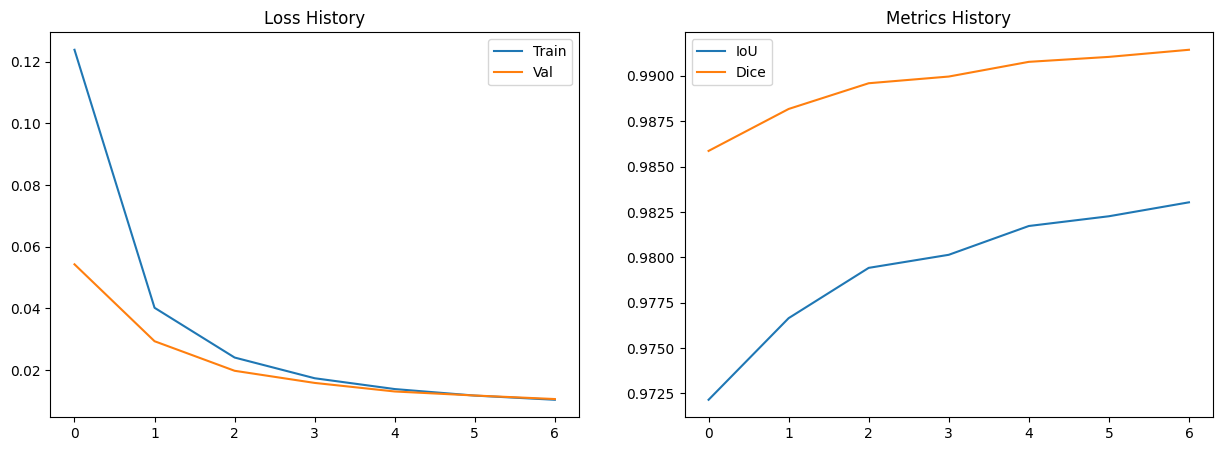

In [20]:
history_BCE = run_training(
    model=model_BCE,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_BCE,
    loss_fn=loss_BCE,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    save_dir='../outputs'
)

In [21]:
loss_Dice = DiceLoss()

In [22]:
model_Dice = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

optimizer_Dice = torch.optim.Adam(model_Dice.parameters(), lr=LEARNING_RATE)

Training: 100%|██████████| 255/255 [02:30<00:00,  1.69it/s, iou=0.966, loss=0.229]


[*] Лучшая модель сохранена (IoU: 0.9599)
Epoch 01 | Val Loss: 0.2466 | IoU: 0.9599 | Dice: 0.9795


Training: 100%|██████████| 255/255 [02:29<00:00,  1.70it/s, iou=0.976, loss=0.0893]


[*] Лучшая модель сохранена (IoU: 0.9758)
Epoch 02 | Val Loss: 0.1000 | IoU: 0.9758 | Dice: 0.9878


Training: 100%|██████████| 255/255 [02:29<00:00,  1.70it/s, iou=0.979, loss=0.0529]


...

[*] Лучшая модель сохранена (IoU: 0.9833)
[EarlyStopping] Счетчик: 1 из 3
Epoch 07 | Val Loss: 0.0160 | IoU: 0.9833 | Dice: 0.9916


Training: 100%|██████████| 255/255 [02:33<00:00,  1.66it/s, iou=0.988, loss=0.0103]


[*] Лучшая модель сохранена (IoU: 0.9842)
[EarlyStopping] Счетчик: 2 из 3
Epoch 08 | Val Loss: 0.0135 | IoU: 0.9842 | Dice: 0.9920


Training: 100%|██████████| 255/255 [02:32<00:00,  1.67it/s, iou=0.987, loss=0.00989]


[*] Лучшая модель сохранена (IoU: 0.9842)
[EarlyStopping] Счетчик: 3 из 3
Ранняя остановка на 09 эпохе


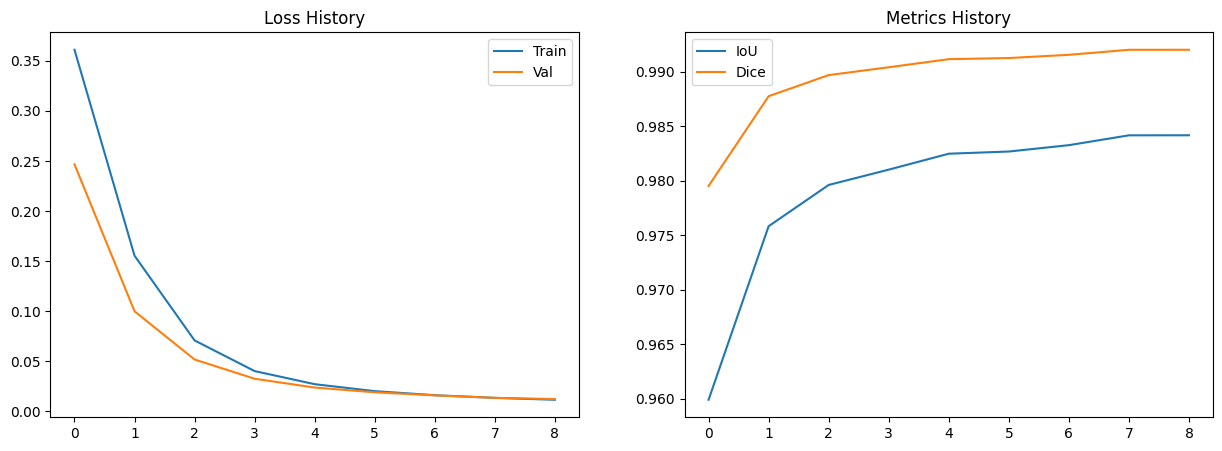

In [23]:
history_Dice = run_training(
    model=model_Dice,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_Dice,
    loss_fn=loss_Dice,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    save_dir='../outputs'
)

In [24]:
loss_BCEDice = BCEDiceLoss()

In [25]:
model_BCEDice = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

optimizer_BCEDice = torch.optim.Adam(model_BCEDice.parameters(), lr=LEARNING_RATE)

Training: 100%|██████████| 255/255 [02:36<00:00,  1.62it/s, iou=0.963, loss=0.0574]


[*] Лучшая модель сохранена (IoU: 0.9730)
Epoch 01 | Val Loss: 0.0578 | IoU: 0.9730 | Dice: 0.9863


Training: 100%|██████████| 255/255 [02:41<00:00,  1.58it/s, iou=0.973, loss=0.0324]


[*] Лучшая модель сохранена (IoU: 0.9764)
Epoch 02 | Val Loss: 0.0318 | IoU: 0.9764 | Dice: 0.9880


Training: 100%|██████████| 255/255 [02:42<00:00,  1.57it/s, iou=0.98, loss=0.0208] 


...

[*] Лучшая модель сохранена (IoU: 0.9811)
[EarlyStopping] Счетчик: 1 из 3
Epoch 04 | Val Loss: 0.0171 | IoU: 0.9811 | Dice: 0.9905


Training: 100%|██████████| 255/255 [02:34<00:00,  1.65it/s, iou=0.985, loss=0.0125]


[*] Лучшая модель сохранена (IoU: 0.9817)
[EarlyStopping] Счетчик: 2 из 3
Epoch 05 | Val Loss: 0.0146 | IoU: 0.9817 | Dice: 0.9907


Training: 100%|██████████| 255/255 [02:41<00:00,  1.58it/s, iou=0.984, loss=0.0126]


[*] Лучшая модель сохранена (IoU: 0.9819)
[EarlyStopping] Счетчик: 3 из 3
Ранняя остановка на 06 эпохе


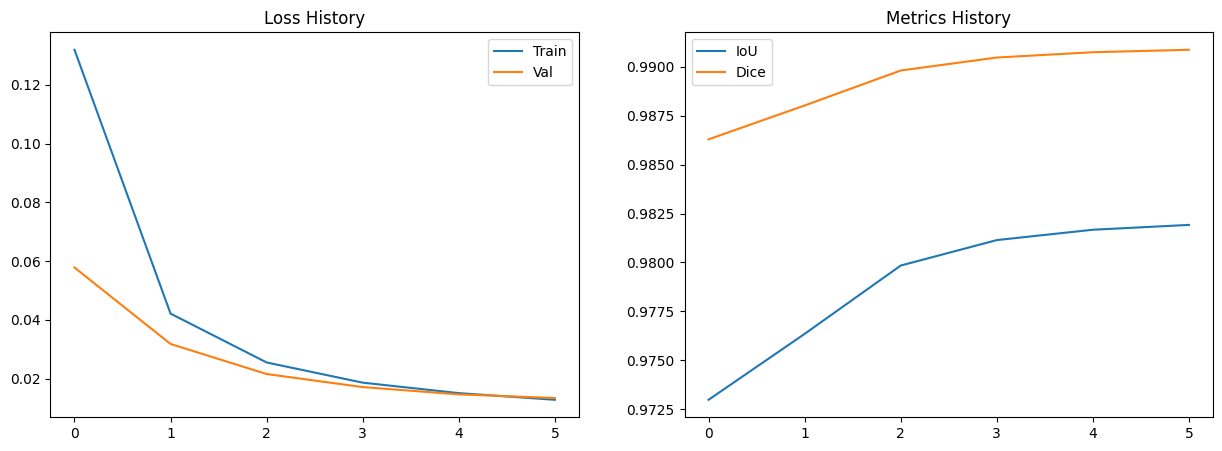

In [26]:
history_BCEDice = run_training(
    model=model_BCEDice,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_BCEDice,
    loss_fn=loss_BCEDice,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    save_dir='../outputs'
)

In [32]:
all_results = {
    'BCEWithLogits': history_BCE,
    'DiceLoss': history_Dice,
    'BCEDiceLoss': history_BCEDice
}

In [43]:
comparison_table = get_best_metrics_table(all_results)
display(comparison_table.style.highlight_max(subset=['Best Val IoU', 'Best Val Dice'], color='green'))

,Loss Function,Best Val IoU,Best Val Dice,Loss at Best IoU,Epochs Trained,Best Epoch
1,DiceLoss,0.984170,0.992016,0.012330,9,9
0,BCEWithLogits,0.983032,0.991437,0.010576,7,7
2,BCEDiceLoss,0.981919,0.990870,0.013355,6,6


In [47]:
trained_models = {
    'BCE': model_BCE,
    'Dice': model_Dice,
    'BCEDice': model_BCEDice
}

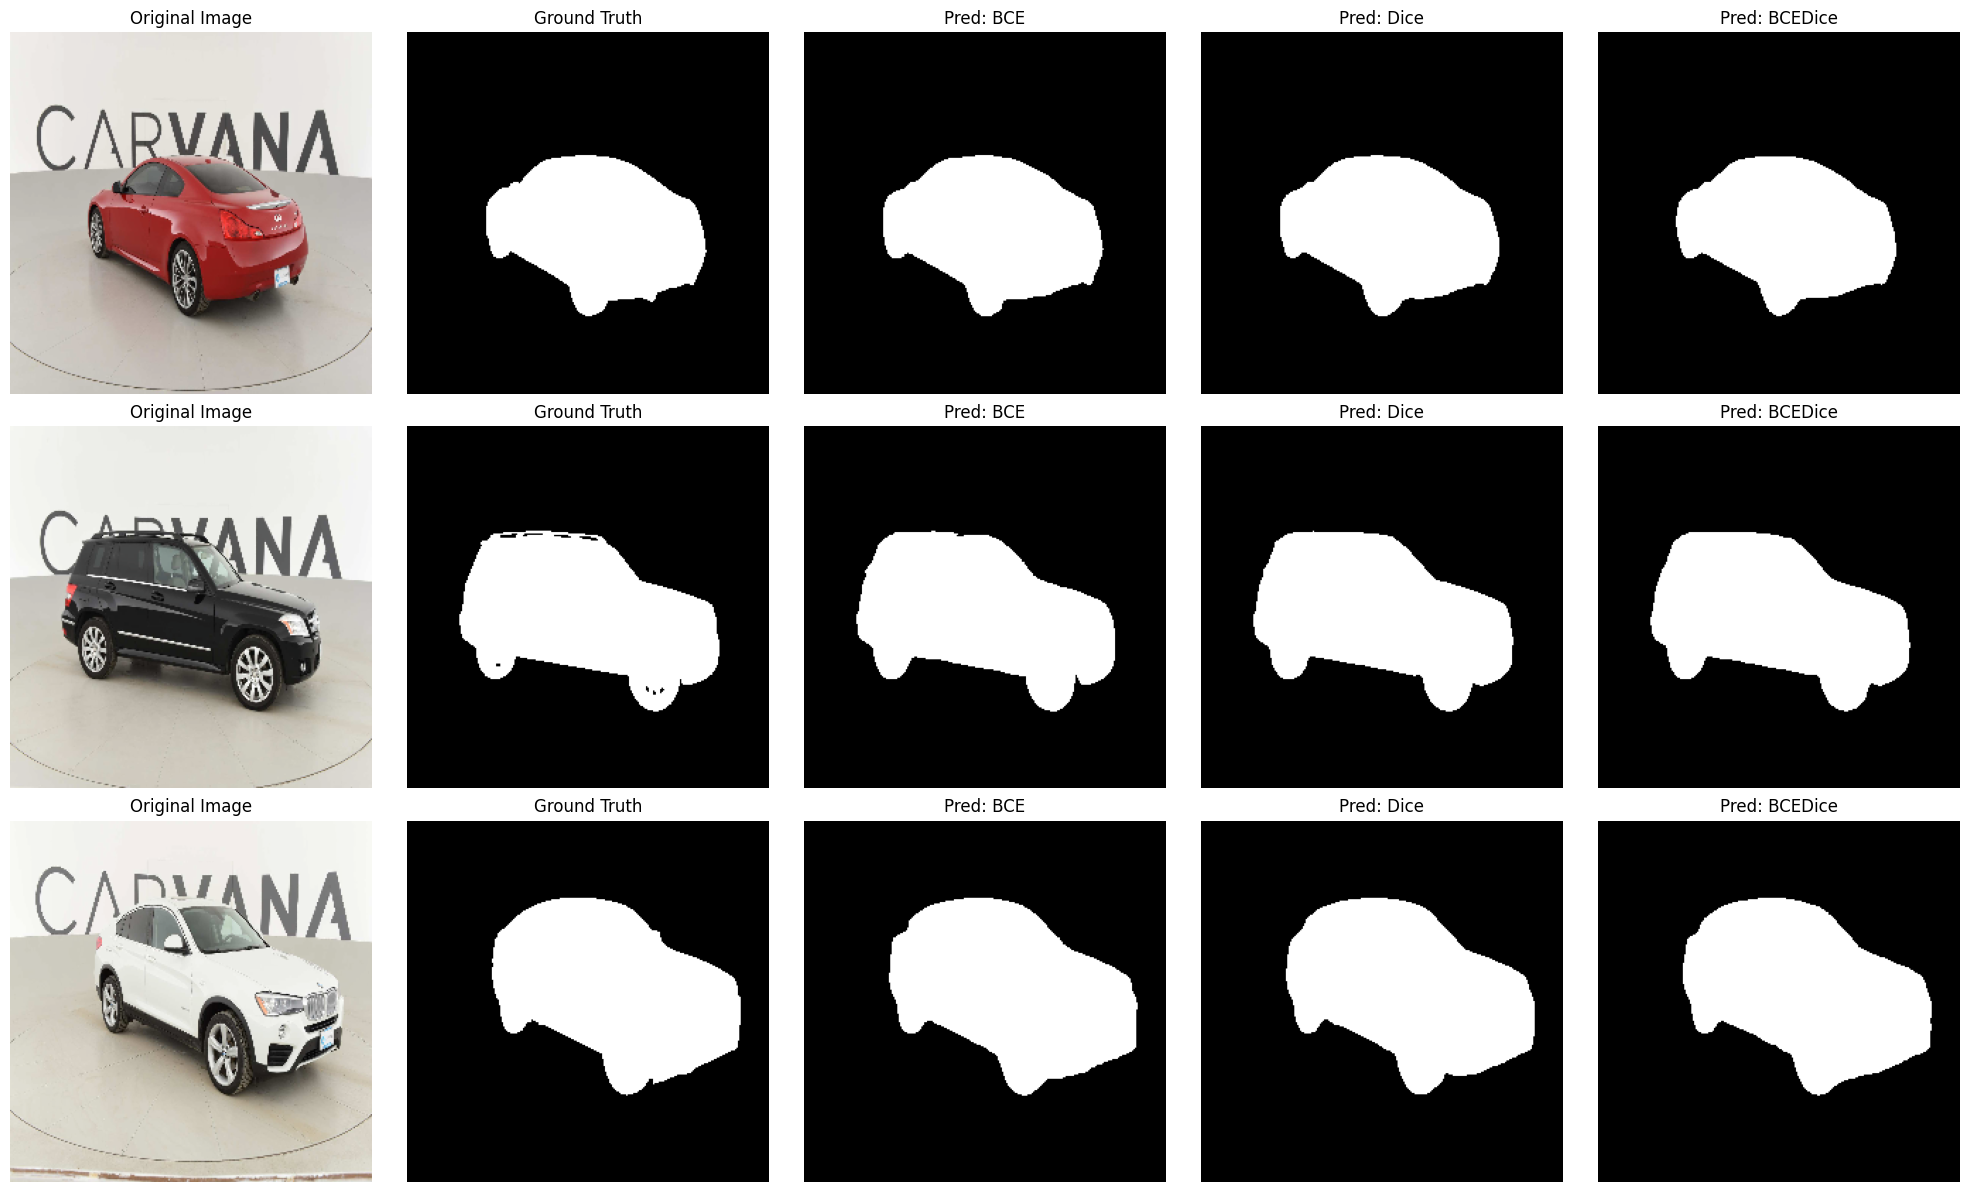

In [48]:
visualize_model_comparison(trained_models, val_subset, DEVICE)

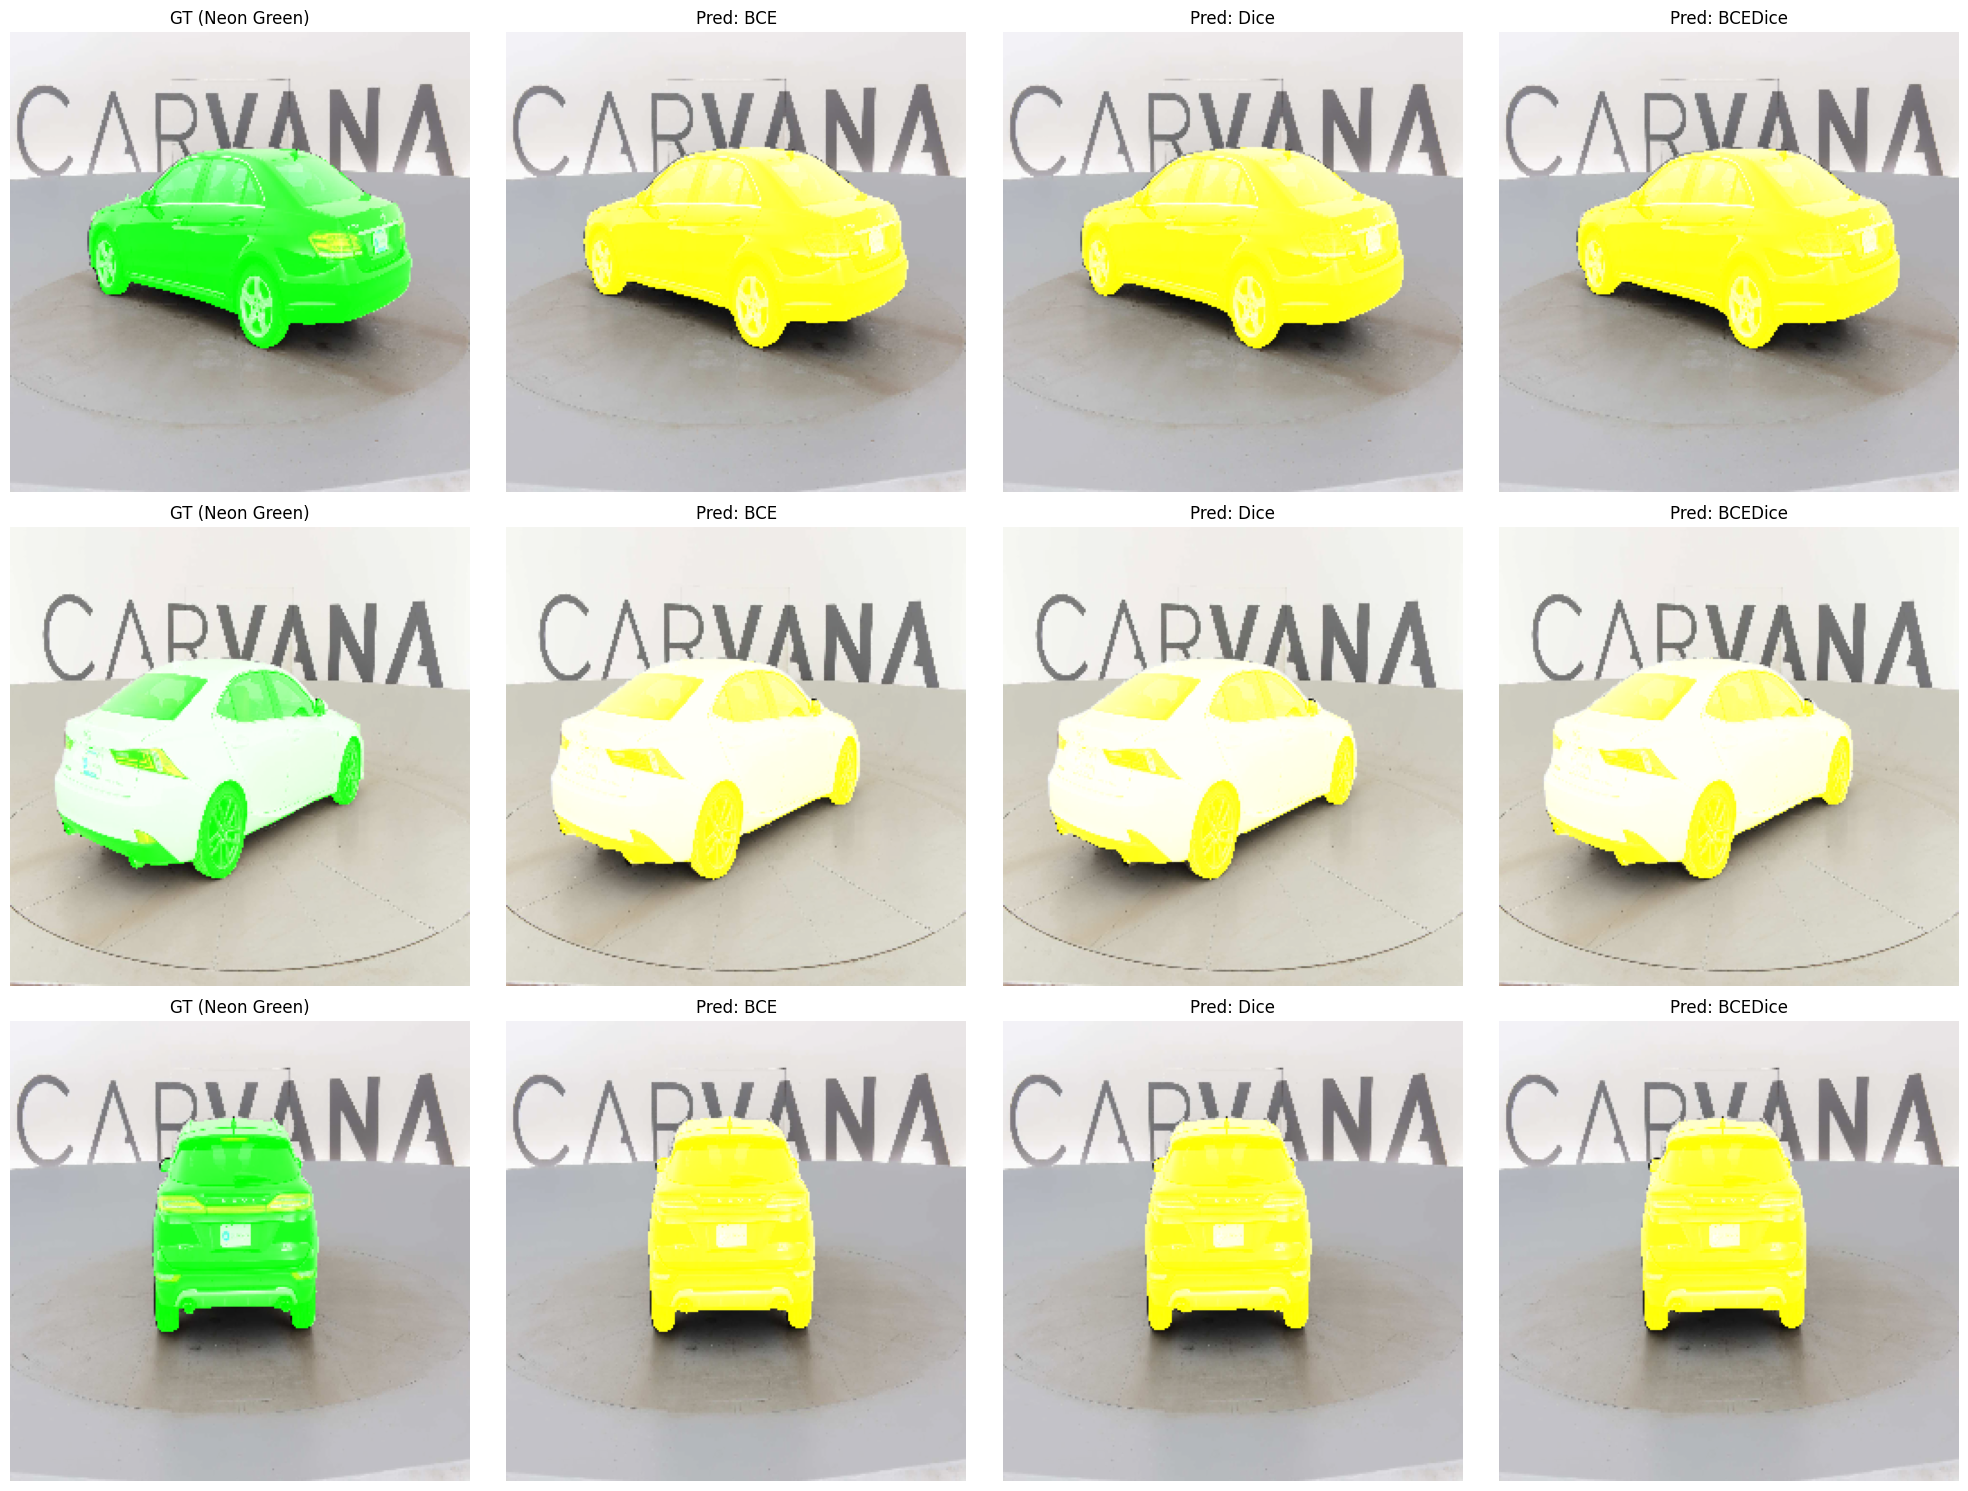

In [55]:
show_results(trained_models, val_subset, DEVICE)